# 🩺 CheXpert Classification with Uncertainty Handling (U-Zeros)

## 📌 Objective
This notebook implements the **U-Zeros uncertainty handling strategy** for multi-label thoracic disease classification using the CheXpert dataset.

In this approach, all uncertain labels (-1) are treated as **Zeros (0)** during training.

---

## 📊 Dataset
- Dataset: CheXpert (Stanford)
- Total Samples: ~220K chest X-rays
- Task: Multi-label classification (13 diseases)
- Labels:
  - `1` → Positive
  - `0` → Negative
  - `-1` → Uncertain (treated as **0 in U-Zeros**)

---

## ⚙️ Workflow Overview
1. Load dataset and inspect structure
2. Clean the Dataset 
3. Handle uncertainty using U-Zeros strategy  
4. Preprocess images and labels  
5. Train deep learning models : ResNet-50, DenseNet-121, CamChex, Multiview
6. Evaluate using classification metrics  
7. Analyze results  

---

## 📦 Libraries Used
- PyTorch (Deep Learning)
- torchvision (Pretrained models & transforms)
- pandas / numpy (Data handling)
- sklearn (Evaluation metrics)
- matplotlib (Visualization)

In [1]:
# Import all the libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [2]:
# Read the train csv
train_df = pd.read_csv("train_cheXbert.csv")

In [3]:
# Look at the shape of the Dataset
print("Shape of dataset:", train_df.shape)
print("\nFirst 5 rows:")
print(train_df.head())

Shape of dataset: (223414, 19)

First 5 rows:
                                                Path     Sex  Age  \
0  CheXpert-v1.0/train/patient00001/study1/view1_...  Female   68   
1  CheXpert-v1.0/train/patient00002/study2/view1_...  Female   87   
2  CheXpert-v1.0/train/patient00002/study1/view1_...  Female   83   
3  CheXpert-v1.0/train/patient00002/study1/view2_...  Female   83   
4  CheXpert-v1.0/train/patient00003/study1/view1_...    Male   41   

  Frontal/Lateral AP/PA  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP                         NaN           NaN   
1         Frontal    AP                         NaN           1.0   
2         Frontal    AP                         NaN           NaN   
3         Lateral   NaN                         NaN           NaN   
4         Frontal    AP                         NaN           NaN   

   Lung Opacity  Lung Lesion  Edema  Consolidation  Pneumonia  Atelectasis  \
0           NaN          NaN    NaN           

In [4]:
# Look at the statistics of the dataset
train_df[['Sex', 'Age']].info()
print("Unique Sex values:", train_df['Sex'].unique()) #Checking Gender Types
print(train_df['Age'].describe()) # Basic stats for Age

<class 'pandas.DataFrame'>
RangeIndex: 223414 entries, 0 to 223413
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   Sex     223414 non-null  str  
 1   Age     223414 non-null  int64
dtypes: int64(1), str(1)
memory usage: 4.4 MB
Unique Sex values: <ArrowStringArray>
['Female', 'Male', 'Unknown']
Length: 3, dtype: str
count    223414.000000
mean         60.527662
std          17.995927
min           0.000000
25%          49.000000
50%          62.000000
75%          74.000000
max         110.000000
Name: Age, dtype: float64


## Data Cleaning

#### 1. Clean the dataset using AGE variable

In [5]:
# Number of patients between age 0 and 17
age_0_17_count = train_df[(train_df['Age'] >= 0) & (train_df['Age'] <= 17)].shape[0]
print("Number of patients between age 0-17 years:", age_0_17_count)

train_df = train_df[train_df['Age'] > 17] # remove them

print("New dataset shape after removing 0-17 age group:", train_df.shape)

Number of patients between age 0-17 years: 3
New dataset shape after removing 0-17 age group: (223411, 19)


#### 2. Clean the dataset using GENDER variable# Count number of "Unknown" in Sex column

In [6]:
# Count number of "Unknown" in Sex column
unknown_count = (train_df['Sex'] == 'Unknown').sum()
print("Number of 'Unknown' Sex values:", unknown_count)

train_df = train_df[train_df['Sex'] != 'Unknown'] #remove them

print("Updated dataset shape:", train_df.shape)

Number of 'Unknown' Sex values: 1
Updated dataset shape: (223410, 19)


In [7]:
# Extract patient ID from Path column
train_df['Patient_ID'] = train_df['Path'].str.extract(r'(patient\d+)')
print(train_df[['Path', 'Patient_ID']].head())

                                                Path    Patient_ID
0  CheXpert-v1.0/train/patient00001/study1/view1_...  patient00001
1  CheXpert-v1.0/train/patient00002/study2/view1_...  patient00002
2  CheXpert-v1.0/train/patient00002/study1/view1_...  patient00002
3  CheXpert-v1.0/train/patient00002/study1/view2_...  patient00002
4  CheXpert-v1.0/train/patient00003/study1/view1_...  patient00003


#### 3. Remove the variable "Support Devices"

In [8]:
train_df = train_df.drop(columns=["Support Devices"])
print(train_df.head())

                                                Path     Sex  Age  \
0  CheXpert-v1.0/train/patient00001/study1/view1_...  Female   68   
1  CheXpert-v1.0/train/patient00002/study2/view1_...  Female   87   
2  CheXpert-v1.0/train/patient00002/study1/view1_...  Female   83   
3  CheXpert-v1.0/train/patient00002/study1/view2_...  Female   83   
4  CheXpert-v1.0/train/patient00003/study1/view1_...    Male   41   

  Frontal/Lateral AP/PA  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP                         NaN           NaN   
1         Frontal    AP                         NaN           1.0   
2         Frontal    AP                         NaN           NaN   
3         Lateral   NaN                         NaN           NaN   
4         Frontal    AP                         NaN           NaN   

   Lung Opacity  Lung Lesion  Edema  Consolidation  Pneumonia  Atelectasis  \
0           NaN          NaN    NaN            NaN        NaN          NaN   
1           1.

#### 4. Clean the dataset with patients with more than 10 images

In [9]:
# Count number of images per patient
images_per_patient = train_df['Patient_ID'].value_counts()

# Patients with more than 10 images
patients_more_than_10 = images_per_patient[images_per_patient > 50]

print("Number of patients with more than 10 images:", len(patients_more_than_10))
print("\nTop patients with many images:")
print(patients_more_than_10.head())

Number of patients with more than 10 images: 63

Top patients with many images:
Patient_ID
patient28746    92
patient33155    92
patient04462    89
patient24163    86
patient34615    85
Name: count, dtype: int64


* NOTE:
  - Patients with more than 10 images - 3522
  - Patients with more than 20 images - 857

In [10]:
# How many images r lost???????????
# patients with >50 images
patients_more_than_50 = images_per_patient[images_per_patient > 50].index

# rows that belong to these patients
rows_to_remove = train_df[train_df['Patient_ID'].isin(patients_more_than_50)]

print("Images that will be removed:", rows_to_remove.shape[0])

total_images = train_df.shape[0]
images_removed = rows_to_remove.shape[0]
percent_removed = (images_removed / total_images) * 100
print(f"Percent of training data removed: {percent_removed:.2f}%")

Images that will be removed: 4032
Percent of training data removed: 1.80%


In [11]:
train_df = train_df[~train_df['Patient_ID'].isin(patients_more_than_50)]
print("Shape after removing patients with >50 images:", train_df.shape)

Shape after removing patients with >50 images: (219378, 19)


## Handling Uncertainty: U Zeros

In [12]:
# Define thoracic findings columns
disease_cols = [
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Lung Lesion',
    'Edema',
    'Consolidation',
    'Pneumonia',
    'Atelectasis',
    'Pneumothorax',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture']

pathology_cols = [col for col in disease_cols if col != 'No Finding'] # Define disease columns
base_df = train_df.copy() # Create a base column
base_df[disease_cols] = base_df[disease_cols].fillna(0) # Fill missing labels with 0

In [13]:
u_zeros_df = base_df.copy()
u_zeros_df[pathology_cols] = u_zeros_df[pathology_cols].replace(-1, 0)
print("\nU-Zeros unique values:")
for col in disease_cols:
    print(f"{col}: {sorted(pd.Series(u_zeros_df[col].dropna().unique()).tolist())}")
model_df = u_zeros_df.copy()


U-Zeros unique values:
No Finding: [0.0, 1.0]
Enlarged Cardiomediastinum: [0.0, 1.0]
Cardiomegaly: [0.0, 1.0]
Lung Opacity: [0.0, 1.0]
Lung Lesion: [0.0, 1.0]
Edema: [0.0, 1.0]
Consolidation: [0.0, 1.0]
Pneumonia: [0.0, 1.0]
Atelectasis: [0.0, 1.0]
Pneumothorax: [0.0, 1.0]
Pleural Effusion: [0.0, 1.0]
Pleural Other: [0.0, 1.0]
Fracture: [0.0, 1.0]


### Filter only frontal images

In [14]:
# model_df = u_zeros_df[u_zeros_df["Frontal/Lateral"] == "Frontal"].copy()

print("Frontal-only shape:", model_df.shape)
print(model_df["Frontal/Lateral"].value_counts())
print("Unique patients:", model_df["Patient_ID"].nunique())

Frontal-only shape: (219378, 19)
Frontal/Lateral
Frontal    187337
Lateral     32041
Name: count, dtype: int64
Unique patients: 64473


### Splitting the dataset

In [15]:
from sklearn.model_selection import train_test_split

In [18]:
# unique patient IDs
patient_ids = model_df["Patient_ID"].unique()

# split patients
train_patients, val_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

# create patient-wise splits
train_split_df = model_df[model_df["Patient_ID"].isin(train_patients)].copy()
val_split_df = model_df[model_df["Patient_ID"].isin(val_patients)].copy()

print("Train split shape:", train_split_df.shape)
print("Val split shape:", val_split_df.shape)

print("Train patients:", train_split_df["Patient_ID"].nunique())
print("Val patients:", val_split_df["Patient_ID"].nunique())

TypeError: only integer scalar arrays can be converted to a scalar index

In [19]:
# Just for verification split is accurate
train_patient_set = set(train_split_df["Patient_ID"].unique())
val_patient_set = set(val_split_df["Patient_ID"].unique())

overlap = train_patient_set.intersection(val_patient_set)
print("Number of overlapping patients:", len(overlap))

NameError: name 'train_split_df' is not defined

## Image Preprocessing

In [17]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, BatchSampler
from PIL import Image
from torch.utils.data import DataLoader

In [19]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),           
    transforms.RandomResizedCrop(
        224, scale=(0.85, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),       
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [20]:
class CheXpertDataset(Dataset):
    def __init__(self, df, label_cols, transform=None):  # removed base_dir
        self.df = df.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rel_path = self.df.loc[idx, "Path"]
        img_path = resolve_path(rel_path)  # uses resolve_path instead

        try:
            image = Image.open(img_path).convert("RGB")
        except (FileNotFoundError, OSError, TypeError):
            image = Image.new("RGB", (224, 224), 0)

        if self.transform:
            image = self.transform(image)

        labels = self.df.loc[idx, self.label_cols].values.astype(np.float32)
        return image, torch.tensor(labels, dtype=torch.float32)

class MultilabelBalancedBatchSampler(BatchSampler):
    """
    Builds batches with:
    - half positive studies (at least one disease present)
    - half negative studies (all disease labels are 0)

    Inside the positive pool, rarer-class samples are favored using
    a rarity score based on inverse class frequency.
    """
    def __init__(self, labels_df, batch_size, pos_fraction=0.5):
        self.labels = labels_df.values.astype(np.float32)
        self.batch_size = batch_size
        self.pos_fraction = pos_fraction

        self.num_pos = max(1, int(batch_size * pos_fraction))
        self.num_neg = batch_size - self.num_pos

        # Positive if any disease is present
        self.positive_mask = (self.labels.sum(axis=1) > 0)
        self.negative_mask = ~self.positive_mask

        self.positive_indices = np.where(self.positive_mask)[0]
        self.negative_indices = np.where(self.negative_mask)[0]

        if len(self.positive_indices) == 0:
            raise ValueError("No positive samples found for balanced batch sampling.")
        if len(self.negative_indices) == 0:
            raise ValueError("No negative samples found for balanced batch sampling.")

        # Class prevalence among training samples
        class_counts = self.labels.sum(axis=0)
        class_inv_freq = 1.0 / (class_counts + 1e-6)

        # Score each positive sample by how many rare classes it contains
        sample_scores = (self.labels * class_inv_freq).sum(axis=1)

        # Keep only positive pool scores
        pos_scores = sample_scores[self.positive_indices]

        # Normalize to a probability distribution
        pos_scores = np.clip(pos_scores, a_min=1e-8, a_max=None)
        self.pos_prob = pos_scores / pos_scores.sum()

        # Negatives sampled uniformly
        self.neg_prob = None

        # Number of batches per epoch
        self.n_batches = len(labels_df) // batch_size

    def __iter__(self):
        for _ in range(self.n_batches):
            pos_batch = np.random.choice(
                self.positive_indices,
                size=self.num_pos,
                replace=True,
                p=self.pos_prob
            )

            neg_batch = np.random.choice(
                self.negative_indices,
                size=self.num_neg,
                replace=True
            )

            batch = np.concatenate([pos_batch, neg_batch])
            np.random.shuffle(batch)

            yield batch.tolist()

    def __len__(self):
        return self.n_batches

In [21]:
import os

BASE = "/home/ubuntu/chexpert/chexpertchestxrays-u20210408"

BATCH_DIRS = [
    f"{BASE}/CheXpert-v1.0 batch 2 (train 1)",
    f"{BASE}/CheXpert-v1.0 batch 3 (train 2)",
    f"{BASE}/CheXpert-v1.0 batch 4 (train 3)",
]

def resolve_path(csv_path):
    # CSV path looks like: CheXpert-v1.0/train/patient00001/study1/view1_frontal.jpg
    relative = csv_path.replace("CheXpert-v1.0/train/", "")
    for batch_dir in BATCH_DIRS:
        candidate = os.path.join(batch_dir, relative)
        if os.path.exists(candidate):
            return candidate
    return None


In [22]:
train_dataset = CheXpertDataset(
    df=train_split_df,
    label_cols=disease_cols,
    transform=train_transform
)

val_dataset = CheXpertDataset(
    df=val_split_df,
    label_cols=disease_cols,
    transform=val_transform
)

balanced_batch_sampler = MultilabelBalancedBatchSampler(
    labels_df=train_split_df[disease_cols],
    batch_size=128,
    pos_fraction=0.5
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=balanced_batch_sampler,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

## Model 2: DenseNet 121

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = len(disease_cols)   # should be 13

densenet121 = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# replace classifier layer
in_features = densenet121.classifier.in_features
densenet121.classifier = nn.Linear(in_features, num_classes)

densenet121 = densenet121.to(device)

print(densenet121)

Using device: cuda
DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [24]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(densenet121.parameters(), lr=1e-4)

In [25]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation", leave=False)

        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

            progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    all_labels = torch.cat(all_labels)
    all_probs = torch.cat(all_probs)

    return epoch_loss, all_labels, all_probs

In [26]:
num_epochs = 3
best_val_loss = float("inf")
best_model_path = "best_densenet121_uzeros.pth"

for epoch in tqdm(range(num_epochs), desc="Epochs"):

    train_loss = train_epoch(densenet121, train_loader, criterion, optimizer, device)

    val_loss, val_labels, val_probs = validate_epoch(
        densenet121, val_loader, criterion, device
    )

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print("-" * 30)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(densenet121.state_dict(), best_model_path)
        print(f"Best model saved to {best_model_path}")

Epochs:   0%|          | 0/3 [00:34<?, ?it/s]                          


KeyboardInterrupt: 

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
best_model_path = "best_densenet121_uzeros.pth"

# Load best model before evaluation
densenet121.load_state_dict(torch.load(best_model_path, weights_only=False))
densenet121 = densenet121.to(device)

val_loss, val_labels, val_probs = validate_epoch(
    densenet121, val_loader, criterion, device
)

# Convert tensors to numpy if needed
if isinstance(val_probs, torch.Tensor):
    val_probs = val_probs.cpu().numpy()

if isinstance(val_labels, torch.Tensor):
    val_labels = val_labels.cpu().numpy()

val_preds = (val_probs >= 0.5).astype(int)

label_cols = [
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Lung Lesion',
    'Edema',
    'Consolidation',
    'Pneumonia',
    'Atelectasis',
    'Pneumothorax',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture'
]

results = []
aurocs = []

for i, disease in enumerate(label_cols):

    y_true = val_labels[:, i]
    y_pred = val_preds[:, i]
    y_prob = val_probs[:, i]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auroc = roc_auc_score(y_true, y_prob)
        aurocs.append(auroc)
    except:
        auroc = np.nan

    results.append({
        "Disease": disease,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUROC": auroc
    })

metrics_df = pd.DataFrame(results)

macro_auroc = np.nanmean(aurocs)

try:
    micro_auroc = roc_auc_score(val_labels.flatten(), val_probs.flatten())
except:
    micro_auroc = np.nan

print("\n=========================")
print(f"Overall Macro AUROC : {macro_auroc:.4f}")
print(f"Overall Micro AUROC : {micro_auroc:.4f}")
print("=========================\n")

metrics_df



Overall Macro AUROC : 0.7753
Overall Micro AUROC : 0.8472



,Disease,Accuracy,Precision,Recall,F1 Score,AUROC
0,No Finding,0.903994,0.000000,0.000000,0.000000,0.817230
1,Enlarged Cardiomediastinum,0.964211,0.333333,0.010410,0.020189,0.673325
2,Cardiomegaly,0.878022,0.611559,0.305523,0.407478,0.822356
3,Lung Opacity,0.640103,0.622158,0.527892,0.571162,0.700475
4,Lung Lesion,0.955246,0.454348,0.110000,0.177119,0.754789
5,Edema,0.804669,0.600424,0.477196,0.531764,0.825508
6,Consolidation,0.926278,0.255300,0.103823,0.147615,0.740119
7,Pneumonia,0.947203,0.143168,0.268367,0.186723,0.796022
8,Atelectasis,0.850483,0.445087,0.011903,0.023186,0.661914
9,Pneumothorax,0.926163,0.584229,0.146188,0.233859,0.828987


ECE: 0.0192


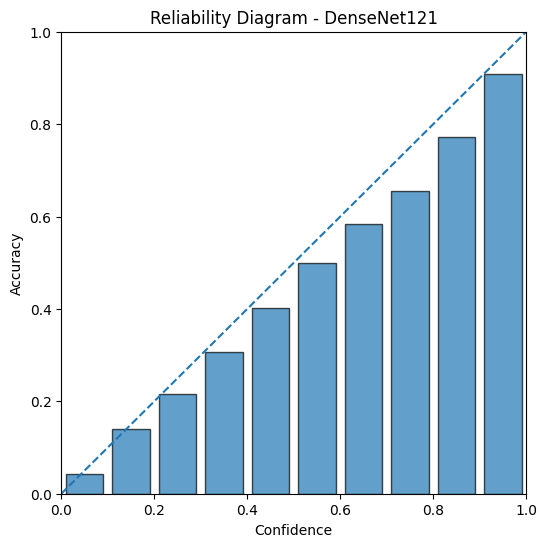

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    for b in range(n_bins):
        mask = bin_ids == b
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            frac = np.mean(mask)

            ece += np.abs(acc - conf) * frac
            bin_accs.append(acc)
            bin_confs.append(conf)
            bin_counts.append(np.sum(mask))
        else:
            bin_accs.append(0.0)
            bin_confs.append(0.0)
            bin_counts.append(0)

    return ece, bins, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)

# Micro-average calibration across all labels
y_true_flat = val_labels.flatten()
y_prob_flat = val_probs.flatten()

ece, bins, bin_accs, bin_confs, bin_counts = compute_ece(y_true_flat, y_prob_flat, n_bins=10)

print(f"ECE: {ece:.4f}")

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.bar(bin_centers, bin_accs, width=0.08, alpha=0.7, edgecolor='black')
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram - DenseNet121")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

### Now, we consider both frontal and lateral images

In [20]:
model_df = u_zeros_df.copy()

model_df["Study_ID"] = model_df["Path"].str.extract(r"(patient\d+/study\d+)")

print("Original rows:", model_df.shape[0])
print("Unique studies:", model_df["Study_ID"].nunique())
print(model_df["Frontal/Lateral"].value_counts(dropna=False))

Original rows: 219378
Unique studies: 183988
Frontal/Lateral
Frontal    187337
Lateral     32041
Name: count, dtype: int64


In [21]:
# We Split into frontal and lateral
frontal_df = model_df[model_df["Frontal/Lateral"] == "Frontal"].copy()
lateral_df = model_df[model_df["Frontal/Lateral"] == "Lateral"].copy()

# Keep only one image per study per view if duplicates exist
frontal_df = frontal_df.sort_values("Path").drop_duplicates(subset=["Study_ID"], keep="first")
lateral_df = lateral_df.sort_values("Path").drop_duplicates(subset=["Study_ID"], keep="first")

print("Frontal studies:", frontal_df["Study_ID"].nunique())
print("Lateral studies:", lateral_df["Study_ID"].nunique())

Frontal studies: 183972
Lateral studies: 31085


In [22]:
# Merge both Frontal and Lateral Images
study_df = frontal_df.merge(
    lateral_df[["Study_ID", "Path"]],
    on="Study_ID",
    how="inner",
    suffixes=("_frontal", "_lateral"))

# Keep labels and metadata from the frontal row and extract patient id again
study_df["Patient_ID"] = study_df["Study_ID"].str.extract(r"(patient\d+)")

print("Dual-view study dataset shape:", study_df.shape)
print("Unique patients:", study_df["Patient_ID"].nunique())
study_df[["Study_ID", "Path_frontal", "Path_lateral"]].head()

Dual-view study dataset shape: (31069, 21)
Unique patients: 22370


,Study_ID,Path_frontal,Path_lateral
0,patient00002/study1,CheXpert-v1.0/train/patient00002/study1/view1_...,CheXpert-v1.0/train/patient00002/study1/view2_...
1,patient00004/study1,CheXpert-v1.0/train/patient00004/study1/view1_...,CheXpert-v1.0/train/patient00004/study1/view2_...
2,patient00005/study1,CheXpert-v1.0/train/patient00005/study1/view1_...,CheXpert-v1.0/train/patient00005/study1/view2_...
3,patient00009/study1,CheXpert-v1.0/train/patient00009/study1/view1_...,CheXpert-v1.0/train/patient00009/study1/view2_...
4,patient00010/study1,CheXpert-v1.0/train/patient00010/study1/view1_...,CheXpert-v1.0/train/patient00010/study1/view2_...


## Splitting the dataset

In [24]:
from sklearn.model_selection import train_test_split

patient_ids = study_df["Patient_ID"].unique()
patient_ids = np.asarray(patient_ids)

train_patients, val_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

train_split_df = study_df[study_df["Patient_ID"].isin(train_patients)].copy()
val_split_df = study_df[study_df["Patient_ID"].isin(val_patients)].copy()

print("Train split shape:", train_split_df.shape)
print("Val split shape:", val_split_df.shape)

print("Train patients:", train_split_df["Patient_ID"].nunique())
print("Val patients:", val_split_df["Patient_ID"].nunique())

Train split shape: (24745, 21)
Val split shape: (6324, 21)
Train patients: 17896
Val patients: 4474


In [25]:
# Verify no patient overlap
train_patient_set = set(train_split_df["Patient_ID"].unique())
val_patient_set = set(val_split_df["Patient_ID"].unique())

overlap = train_patient_set.intersection(val_patient_set)
print("Number of overlapping patients:", len(overlap))

Number of overlapping patients: 0


In [26]:
# Check label prevalence
print("Train label prevalence:")
print(train_split_df[disease_cols].mean().sort_values(ascending=False))

print("\nValidation label prevalence:")
print(val_split_df[disease_cols].mean().sort_values(ascending=False))

Train label prevalence:
Lung Opacity                  0.327096
Pleural Effusion              0.295090
No Finding                    0.161245
Cardiomegaly                  0.129521
Atelectasis                   0.113397
Edema                         0.075975
Lung Lesion                   0.069590
Consolidation                 0.047969
Pneumothorax                  0.047727
Fracture                      0.047404
Enlarged Cardiomediastinum    0.035603
Pneumonia                     0.035482
Pleural Other                 0.035361
dtype: float64

Validation label prevalence:
Lung Opacity                  0.323055
Pleural Effusion              0.287634
No Finding                    0.159709
Cardiomegaly                  0.130455
Atelectasis                   0.116856
Edema                         0.078748
Lung Lesion                   0.062935
Pneumothorax                  0.050917
Fracture                      0.044750
Consolidation                 0.038109
Pleural Other                 0.03

## Image Preprocessing 2

## Model 3: CamChex

In [27]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, BatchSampler
from torchvision import models, transforms
from torch.cuda.amp import GradScaler, autocast
from PIL import Image
from tqdm import tqdm

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.backends.cudnn.benchmark = True
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ── Path resolution ───────────────────────────────────────────────────────────
BASE = "/home/ubuntu/chexpert/chexpertchestxrays-u20210408"
BATCH_DIRS = [
    f"{BASE}/CheXpert-v1.0 batch 2 (train 1)",
    f"{BASE}/CheXpert-v1.0 batch 3 (train 2)",
    f"{BASE}/CheXpert-v1.0 batch 4 (train 3)",
]

def resolve_path(csv_path):
    relative = csv_path.replace("CheXpert-v1.0/train/", "")
    for batch_dir in BATCH_DIRS:
        candidate = os.path.join(batch_dir, relative)
        if os.path.exists(candidate):
            return candidate
    return None

Using device: cuda


In [28]:
# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [29]:
# ── Dataset ───────────────────────────────────────────────────────────────────
class CheXpertDualViewDataset(Dataset):
    def __init__(self, df, label_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform = transform
        print(f"Dataset size: {len(self.df)} studies")

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        img_path = resolve_path(path)
        try:
            image = Image.open(img_path).convert("RGB")
        except (FileNotFoundError, OSError, TypeError):
            image = Image.new("RGB", (224, 224), 0)
        if self.transform:
            image = self.transform(image)
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frontal_img = self._load_image(row["Path_frontal"])
        lateral_img = self._load_image(row["Path_lateral"])
        labels = row[self.label_cols].values.astype(np.float32)
        return frontal_img, lateral_img, torch.tensor(labels, dtype=torch.float32)

In [30]:
# ── Balanced Batch Sampler ────────────────────────────────────────────────────
class MultilabelBalancedBatchSampler(BatchSampler):
    """
    Builds batches with:
    - half positive studies (at least one disease present)
    - half negative studies (all disease labels are 0)
    Inside the positive pool, rarer-class samples are favored using
    a rarity score based on inverse class frequency.
    """
    def __init__(self, labels_df, batch_size, pos_fraction=0.5):
        self.labels = labels_df.values.astype(np.float32)
        self.batch_size = batch_size
        self.num_pos = max(1, int(batch_size * pos_fraction))
        self.num_neg = batch_size - self.num_pos

        self.positive_mask = (self.labels.sum(axis=1) > 0)
        self.negative_mask = ~self.positive_mask
        self.positive_indices = np.where(self.positive_mask)[0]
        self.negative_indices = np.where(self.negative_mask)[0]

        if len(self.positive_indices) == 0:
            raise ValueError("No positive samples found.")
        if len(self.negative_indices) == 0:
            raise ValueError("No negative samples found.")

        class_counts = self.labels.sum(axis=0)
        class_inv_freq = 1.0 / (class_counts + 1e-6)
        sample_scores = (self.labels * class_inv_freq).sum(axis=1)
        pos_scores = np.clip(sample_scores[self.positive_indices], 1e-8, None)
        self.pos_prob = pos_scores / pos_scores.sum()
        self.n_batches = len(labels_df) // batch_size

    def __iter__(self):
        for _ in range(self.n_batches):
            pos_batch = np.random.choice(
                self.positive_indices, size=self.num_pos,
                replace=True, p=self.pos_prob
            )
            neg_batch = np.random.choice(
                self.negative_indices, size=self.num_neg,
                replace=True
            )
            batch = np.concatenate([pos_batch, neg_batch])
            np.random.shuffle(batch)
            yield batch.tolist()

    def __len__(self):
        return self.n_batches

In [31]:
# ── Model ─────────────────────────────────────────────────────────────────────
class CaMCheXDualView(nn.Module):
    """
    Dual-view CheXpert model.

    Memory options (set at init):
      shared_weights=True  → one backbone, run twice  (~halves param memory)
      use_checkpointing=True → gradient checkpointing (~halves activation memory)
    """
    def __init__(self, num_classes, shared_weights=True, use_checkpointing=True):
        super().__init__()
        self.use_checkpointing = use_checkpointing

        backbone = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.DEFAULT
        )
        in_features = backbone.classifier[2].in_features
        backbone.classifier = nn.Identity()

        if shared_weights:
            # One backbone, called twice — halves parameter memory
            self.frontal_encoder = backbone
            self.lateral_encoder = backbone
        else:
            # Two independent backbones
            import copy
            self.frontal_encoder = backbone
            self.lateral_encoder = copy.deepcopy(backbone)

        self.classifier = nn.Sequential(
            nn.Linear(in_features * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def _encode(self, encoder, x):
        if self.use_checkpointing and self.training:
            return torch.utils.checkpoint.checkpoint(
                encoder, x, use_reentrant=False
            )
        return encoder(x)

    def forward(self, frontal_img, lateral_img):
        frontal_feat = torch.flatten(self._encode(self.frontal_encoder, frontal_img), 1)
        lateral_feat = torch.flatten(self._encode(self.lateral_encoder, lateral_img), 1)
        return self.classifier(torch.cat([frontal_feat, lateral_feat], dim=1))

In [32]:
# ── Datasets & Loaders ────────────────────────────────────────────────────────
BATCH_SIZE = 32

print("Building train dataset...")
train_dataset = CheXpertDualViewDataset(
    df=train_split_df,
    label_cols=disease_cols,
    transform=train_transform
)

print("Building val dataset...")
val_dataset = CheXpertDualViewDataset(
    df=val_split_df,
    label_cols=disease_cols,
    transform=val_transform
)

balanced_batch_sampler = MultilabelBalancedBatchSampler(
    labels_df=train_dataset.df[disease_cols],
    batch_size=BATCH_SIZE
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=balanced_batch_sampler,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)



Building train dataset...
Dataset size: 24745 studies
Building val dataset...
Dataset size: 6324 studies


In [33]:
# ── Model / Optimizer / Loss ──────────────────────────────────────────────────
camchex = CaMCheXDualView(
    num_classes=len(disease_cols),
    shared_weights=True,       # ← set False to restore independent backbones
    use_checkpointing=True     # ← trades compute for activation memory
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(camchex.parameters(), lr=1e-4, weight_decay=1e-2)
scaler    = GradScaler()   # mixed precision — fp16 forward, fp32 gradients

# Sanity check
with torch.no_grad():
    f = torch.randn(2, 3, 224, 224).to(device)
    l = torch.randn(2, 3, 224, 224).to(device)
    print(f"Model output shape: {camchex(f, l).shape}")
    del f, l
torch.cuda.empty_cache()

/tmp/ipykernel_1899/2881516902.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()   # mixed precision — fp16 forward, fp32 gradients


Model output shape: torch.Size([2, 13])


In [34]:
# ── Train / Val Functions ─────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    for frontal_imgs, lateral_imgs, labels in tqdm(loader, desc="Training", leave=False):
        frontal_imgs = frontal_imgs.to(device, non_blocking=True)
        lateral_imgs = lateral_imgs.to(device, non_blocking=True)
        labels       = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast():                                      # fp16 forward pass
            loss = criterion(model(frontal_imgs, lateral_imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels, all_probs = [], []
    with torch.no_grad():
        for frontal_imgs, lateral_imgs, labels in tqdm(loader, desc="Validation", leave=False):
            frontal_imgs = frontal_imgs.to(device, non_blocking=True)
            lateral_imgs = lateral_imgs.to(device, non_blocking=True)
            labels       = labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(frontal_imgs, lateral_imgs)
            running_loss += criterion(outputs, labels).item() * labels.size(0)
            all_labels.append(labels.cpu())
            all_probs.append(torch.sigmoid(outputs).cpu())
    return (
        running_loss / len(loader.dataset),
        torch.cat(all_labels),
        torch.cat(all_probs)
    )



In [ ]:
# ── Training Run ──────────────────────────────────────────────────────────────
num_epochs      = 5
best_val_loss   = float("inf")
best_model_path = "best_camchex_uzeros.pth"

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    torch.cuda.empty_cache()   # clear fragmentation between epochs

    train_loss = train_epoch(
        camchex, train_loader, criterion, optimizer, scaler, device
    )
    val_loss, val_labels, val_probs = validate_epoch(
        camchex, val_loader, criterion, device
    )

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print("-" * 30)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(camchex.state_dict(), best_model_path)
        print(f"  Best model saved → {best_model_path}")

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

best_model_path = "best_camchex_uzeros.pth"
# Load best model before evaluation
camchex.load_state_dict(torch.load(best_model_path, map_location=device))
camchex = camchex.to(device)

val_loss, val_labels, val_probs = validate_epoch(
    camchex, val_loader, criterion, device
)

if isinstance(val_probs, torch.Tensor):
    val_probs = val_probs.cpu().numpy()

if isinstance(val_labels, torch.Tensor):
    val_labels = val_labels.cpu().numpy()

val_preds = (val_probs >= 0.5).astype(int)

results = []
aurocs = []

for i, disease in enumerate(disease_cols):

    y_true = val_labels[:, i]
    y_pred = val_preds[:, i]
    y_prob = val_probs[:, i]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auroc = roc_auc_score(y_true, y_prob)
        aurocs.append(auroc)
    except:
        auroc = np.nan

    results.append({
        "Disease": disease,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUROC": auroc
    })

metrics_df = pd.DataFrame(results)

macro_auroc = np.nanmean(aurocs)

try:
    micro_auroc = roc_auc_score(val_labels.flatten(), val_probs.flatten())
except:
    micro_auroc = np.nan

print("\n=========================")
print(f"Overall Macro AUROC : {macro_auroc:.4f}")
print(f"Overall Micro AUROC : {micro_auroc:.4f}")
print("=========================\n")

metrics_df

Validation:   0%|          | 0/198 [00:00<?, ?it/s]/tmp/ipykernel_18917/2567635373.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                             


Overall Macro AUROC : 0.6656
Overall Micro AUROC : 0.7289



,Disease,Accuracy,Precision,Recall,F1 Score,AUROC
0,No Finding,0.840291,0.000000,0.000000,0.000000,0.788084
1,Enlarged Cardiomediastinum,0.964421,0.000000,0.000000,0.000000,0.532503
2,Cardiomegaly,0.801550,0.277893,0.326061,0.300056,0.664629
3,Lung Opacity,0.661607,0.480180,0.575135,0.523385,0.690795
4,Lung Lesion,0.937065,0.000000,0.000000,0.000000,0.604435
5,Edema,0.920462,0.459016,0.056225,0.100179,0.773834
6,Consolidation,0.961891,0.000000,0.000000,0.000000,0.684848
7,Pneumonia,0.969007,0.000000,0.000000,0.000000,0.645872
8,Atelectasis,0.883144,0.000000,0.000000,0.000000,0.584208
9,Pneumothorax,0.949083,0.000000,0.000000,0.000000,0.699117


ECE: 0.0432


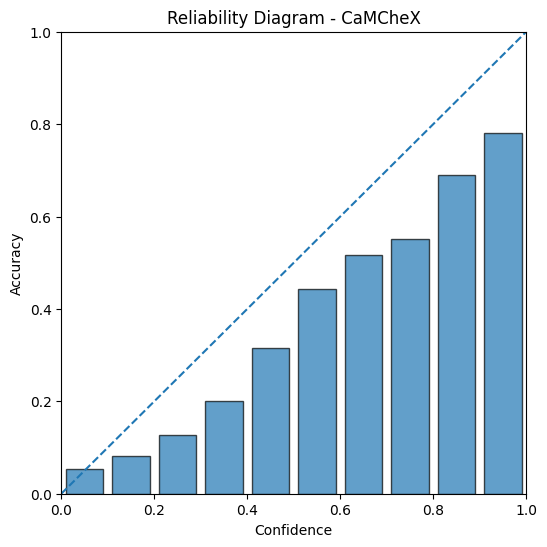

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    for b in range(n_bins):
        mask = bin_ids == b
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            frac = np.mean(mask)

            ece += np.abs(acc - conf) * frac
            bin_accs.append(acc)
            bin_confs.append(conf)
            bin_counts.append(np.sum(mask))
        else:
            bin_accs.append(0.0)
            bin_confs.append(0.0)
            bin_counts.append(0)

    return ece, bins, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)

# Micro-average calibration across all labels
y_true_flat = val_labels.flatten()
y_prob_flat = val_probs.flatten()

ece, bins, bin_accs, bin_confs, bin_counts = compute_ece(y_true_flat, y_prob_flat, n_bins=10)

print(f"ECE: {ece:.4f}")

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.bar(bin_centers, bin_accs, width=0.08, alpha=0.7, edgecolor='black')
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram - CaMCheX")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Handling Uncertianty in Models: DenseNet & CamChex

##  1. Monte carlo Dropout

In [45]:
import torch
import numpy as np
from torch import nn

def enable_dropout(model):
    """Enable dropout layers during inference for MC Dropout"""
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

def mc_dropout_inference(model, loader, device, T=30, dual_view=False):
    """
    Run T stochastic forward passes with dropout enabled.
    Returns:
        all_samples  : (N, T, num_classes) — raw probability samples
        all_labels   : (N, num_classes)    — ground truth
    """
    model.eval()
    enable_dropout(model)  # keep dropout ON

    all_samples = []
    all_labels  = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"MC Dropout (T={T})", leave=False):

            if dual_view:
                frontal_imgs, lateral_imgs, labels = batch
                frontal_imgs = frontal_imgs.to(device)
                lateral_imgs = lateral_imgs.to(device)
            else:
                images, labels = batch
                images = images.to(device)

            batch_size = labels.shape[0]
            batch_samples = []

            for t in range(T):
                if dual_view:
                    # DenseNet121 paper style — max probability fusion
                    frontal_out = model(frontal_imgs)
                    lateral_out = model(lateral_imgs)
                    logits = torch.max(frontal_out, lateral_out)
                else:
                    logits = model(images)

                probs = torch.sigmoid(logits).cpu().numpy()
                batch_samples.append(probs)

            # Stack T passes → (T, batch, classes) → (batch, T, classes)
            batch_samples = np.stack(batch_samples, axis=0).transpose(1, 0, 2)
            all_samples.append(batch_samples)
            all_labels.append(labels.numpy())

    all_samples = np.concatenate(all_samples, axis=0)  # (N, T, C)
    all_labels  = np.concatenate(all_labels,  axis=0)  # (N, C)

    return all_samples, all_labels

## Uncertainty Methods

In [46]:
def compute_uncertainty_metrics(samples):
    """
    samples: (N, T, C) — MC Dropout probability samples

    Returns dict with:
        mean_pred         : (N, C) — mean prediction across T passes
        predictive_entropy: (N, C) — overall uncertainty (Shannon entropy)
        mutual_information: (N, C) — epistemic uncertainty
        aleatoric         : (N, C) — aleatoric uncertainty
    """
    eps = 1e-8

    # Mean prediction across T passes
    mean_pred = samples.mean(axis=1)  # (N, C)

    # Predictive Entropy — H[E[p(y|x,w)]]
    # Higher = more uncertain overall
    pred_entropy = -(
        mean_pred * np.log(mean_pred + eps) +
        (1 - mean_pred) * np.log(1 - mean_pred + eps)
    )  # (N, C)

    # Expected Entropy — E[H[p(y|x,w)]] = aleatoric uncertainty
    sample_entropy = -(
        samples * np.log(samples + eps) +
        (1 - samples) * np.log(1 - samples + eps)
    )  # (N, T, C)
    aleatoric = sample_entropy.mean(axis=1)  # (N, C)

    # Mutual Information = Predictive Entropy - Aleatoric
    # = epistemic uncertainty (reducible with more data/training)
    mutual_info = pred_entropy - aleatoric  # (N, C)
    mutual_info = np.clip(mutual_info, 0, None)  # numerical safety

    return {
        'mean_pred':          mean_pred,
        'predictive_entropy': pred_entropy,
        'mutual_information': mutual_info,
        'aleatoric':          aleatoric
    }

## DenseNet-121

In [47]:
import torch.nn.functional as F

class DenseNet121WithDropout(nn.Module):
    def __init__(self, original_model, dropout_p=0.3):
        super().__init__()
        self.features   = original_model.features
        self.dropout    = nn.Dropout(p=dropout_p)
        self.classifier = original_model.classifier

    def forward(self, x):
        features = self.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        out = self.dropout(out)
        out = self.classifier(out)
        return out

# Wrap existing densenet121
densenet121_mc = DenseNet121WithDropout(densenet121, dropout_p=0.3).to(device)

# Load raw state dict directly — no nesting in .pth file
state_dict = torch.load(
    'best_densenet121_uzeros.pth',
    map_location=device,
    weights_only=False
)

# Load features
densenet121_mc.features.load_state_dict(
    {k.replace('features.', ''): v
     for k, v in state_dict.items()
     if k.startswith('features.')}
)

# Load classifier
densenet121_mc.classifier.load_state_dict(
    {k.replace('classifier.', ''): v
     for k, v in state_dict.items()
     if k.startswith('classifier.')}
)

print("Wrapped model ready with dropout p=0.3")
print(f"Features keys sample: {[k for k in state_dict.keys() if k.startswith('features.')][:3]}")
print(f"Classifier keys: {[k for k in state_dict.keys() if k.startswith('classifier.')]}")

Wrapped model ready with dropout p=0.3
Features keys sample: ['features.conv0.weight', 'features.norm0.weight', 'features.norm0.bias']
Classifier keys: ['classifier.weight', 'classifier.bias']


In [49]:
def enable_dropout(model):
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()
            print(f"  Enabled dropout: p={module.p}")

# Verify dropout is enabled
model_to_use = densenet121_mc
model_to_use.eval()
enable_dropout(model_to_use)

# Rerun MC Dropout
print("\nRunning MC Dropout for DenseNet121 (with injected dropout)...")
densenet_samples, densenet_labels = mc_dropout_inference(
    model=model_to_use,
    loader=val_loader,
    device=device,
    T=30,
    dual_view=False
)

densenet_uncertainty = compute_uncertainty_metrics(densenet_samples)

print("\nDenseNet121 — Mean Uncertainty per Disease:")
print(f"{'Disease':<30} {'Pred Entropy':>14} {'Mutual Info':>13} {'Aleatoric':>11}")
print("-" * 72)
for i, disease in enumerate(disease_cols):
    pe = densenet_uncertainty['predictive_entropy'][:, i].mean()
    mi = densenet_uncertainty['mutual_information'][:, i].mean()
    al = densenet_uncertainty['aleatoric'][:, i].mean()
    print(f"{disease:<30} {pe:>14.4f} {mi:>13.4f} {al:>11.4f}")

  Enabled dropout: p=0.3

Running MC Dropout for DenseNet121 (with injected dropout)...
  Enabled dropout: p=0.3



DenseNet121 — Mean Uncertainty per Disease:
Disease                          Pred Entropy   Mutual Info   Aleatoric
------------------------------------------------------------------------
No Finding                             0.1195        0.0017      0.1179
Enlarged Cardiomediastinum             0.1968        0.0038      0.1930
Cardiomegaly                           0.2586        0.0051      0.2535
Lung Opacity                           0.5153        0.0097      0.5056
Lung Lesion                            0.2105        0.0043      0.2062
Edema                                  0.3628        0.0070      0.3558
Consolidation                          0.3162        0.0059      0.3103
Pneumonia                              0.2193        0.0052      0.2142
Atelectasis                            0.3537        0.0063      0.3474
Pneumothorax                           0.2065        0.0046      0.2020
Pleural Effusion                       0.3688        0.0083      0.3605
Pleural Other     

## CamChex

In [64]:
def mc_dropout_inference(model, loader, device, T=30, dual_view=False):
    model.eval()
    enable_dropout(model)

    all_samples = []
    all_labels  = []

    # Auto-detect if model is CaMCheX (native dual input)
    is_camchex = hasattr(model, 'frontal_encoder')

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"MC Dropout (T={T})", leave=False):

            if dual_view:
                frontal_imgs, lateral_imgs, labels = batch
                frontal_imgs = frontal_imgs.to(device)
                lateral_imgs = lateral_imgs.to(device)
            else:
                images, labels = batch
                images = images.to(device)

            batch_samples = []

            for t in range(T):
                if dual_view:
                    if is_camchex:
                        # CaMCheX — takes both views as separate inputs
                        logits = model(frontal_imgs, lateral_imgs)
                    else:
                        # DenseNet121 — max probability fusion
                        frontal_out = model(frontal_imgs)
                        lateral_out = model(lateral_imgs)
                        logits = torch.max(frontal_out, lateral_out)
                else:
                    logits = model(images)

                probs = torch.sigmoid(logits).cpu().numpy()
                batch_samples.append(probs)

            batch_samples = np.stack(batch_samples, axis=0).transpose(1, 0, 2)
            all_samples.append(batch_samples)
            all_labels.append(labels.numpy())

    all_samples = np.concatenate(all_samples, axis=0)
    all_labels  = np.concatenate(all_labels,  axis=0)

    return all_samples, all_labels

In [65]:
# Load best CaMCheX
checkpoint = torch.load('best_camchex_uzeros.pth', map_location=device, weights_only=False)
camchex.load_state_dict(checkpoint)
camchex = camchex.to(device)
print("CaMCheX loaded successfully")

# Run MC Dropout
print("Running MC Dropout for CaMCheX...")
camchex_samples, camchex_labels = mc_dropout_inference(
    model=camchex,
    loader=val_loader,
    device=device,
    T=30,
    dual_view=True  # CaMCheX uses frontal + lateral natively
)

# Compute uncertainty metrics
camchex_uncertainty = compute_uncertainty_metrics(camchex_samples)

# Summary per disease
print("\nCaMCheX — Mean Uncertainty per Disease:")
print(f"{'Disease':<30} {'Pred Entropy':>14} {'Mutual Info':>13} {'Aleatoric':>11}")
print("-" * 72)
for i, disease in enumerate(disease_cols):
    pe = camchex_uncertainty['predictive_entropy'][:, i].mean()
    mi = camchex_uncertainty['mutual_information'][:, i].mean()
    al = camchex_uncertainty['aleatoric'][:, i].mean()
    print(f"{disease:<30} {pe:>14.4f} {mi:>13.4f} {al:>11.4f}")

CaMCheX loaded successfully
Running MC Dropout for CaMCheX...
  Enabled dropout: p=0.3



CaMCheX — Mean Uncertainty per Disease:
Disease                          Pred Entropy   Mutual Info   Aleatoric
------------------------------------------------------------------------
No Finding                             0.6928        0.0001      0.6927
Enlarged Cardiomediastinum             0.6930        0.0001      0.6929
Cardiomegaly                           0.6930        0.0001      0.6929
Lung Opacity                           0.6931        0.0001      0.6930
Lung Lesion                            0.6928        0.0001      0.6927
Edema                                  0.6927        0.0001      0.6926
Consolidation                          0.6931        0.0001      0.6930
Pneumonia                              0.6930        0.0001      0.6930
Atelectasis                            0.6931        0.0001      0.6930
Pneumothorax                           0.6929        0.0001      0.6929
Pleural Effusion                       0.6931        0.0001      0.6930
Pleural Other         

In [66]:
import pandas as pd

comparison = []
for i, disease in enumerate(disease_cols):
    comparison.append({
        'Disease': disease,
        # DenseNet
        'DN_PredEntropy': densenet_uncertainty['predictive_entropy'][:, i].mean(),
        'DN_MutualInfo':  densenet_uncertainty['mutual_information'][:, i].mean(),
        'DN_Aleatoric':   densenet_uncertainty['aleatoric'][:, i].mean(),
        # CaMCheX
        'CX_PredEntropy': camchex_uncertainty['predictive_entropy'][:, i].mean(),
        'CX_MutualInfo':  camchex_uncertainty['mutual_information'][:, i].mean(),
        'CX_Aleatoric':   camchex_uncertainty['aleatoric'][:, i].mean(),
    })

comp_df = pd.DataFrame(comparison)

print("\n========== UNCERTAINTY COMPARISON ==========")
print("Lower entropy = more confident model\n")
display(comp_df.round(4))

# Overall summary
print("\nOverall Mean Uncertainty:")
print(f"{'Metric':<25} {'DenseNet121':>12} {'CaMCheX':>10}")
print("-" * 50)
print(f"{'Predictive Entropy':<25} {comp_df['DN_PredEntropy'].mean():>12.4f} {comp_df['CX_PredEntropy'].mean():>10.4f}")
print(f"{'Mutual Information':<25} {comp_df['DN_MutualInfo'].mean():>12.4f} {comp_df['CX_MutualInfo'].mean():>10.4f}")
print(f"{'Aleatoric':<25} {comp_df['DN_Aleatoric'].mean():>12.4f} {comp_df['CX_Aleatoric'].mean():>10.4f}")


========== UNCERTAINTY COMPARISON ==========
Lower entropy = more confident model



,Disease,DN_PredEntropy,DN_MutualInfo,DN_Aleatoric,CX_PredEntropy,CX_MutualInfo,CX_Aleatoric
0,No Finding,0.1195,0.0017,0.1179,0.6928,0.0001,0.6927
1,Enlarged Cardiomediastinum,0.1968,0.0038,0.1930,0.6930,0.0001,0.6929
2,Cardiomegaly,0.2586,0.0051,0.2535,0.6930,0.0001,0.6929
3,Lung Opacity,0.5153,0.0097,0.5056,0.6931,0.0001,0.6930
4,Lung Lesion,0.2105,0.0043,0.2062,0.6928,0.0001,0.6927
5,Edema,0.3628,0.0070,0.3558,0.6927,0.0001,0.6926
6,Consolidation,0.3162,0.0059,0.3103,0.6931,0.0001,0.6930
7,Pneumonia,0.2193,0.0052,0.2142,0.6930,0.0001,0.6930
8,Atelectasis,0.3537,0.0063,0.3474,0.6931,0.0001,0.6930
9,Pneumothorax,0.2065,0.0046,0.2020,0.6929,0.0001,0.6929



Overall Mean Uncertainty:
Metric                     DenseNet121    CaMCheX
--------------------------------------------------
Predictive Entropy              0.2642     0.6930
Mutual Information              0.0053     0.0001
Aleatoric                       0.2589     0.6929


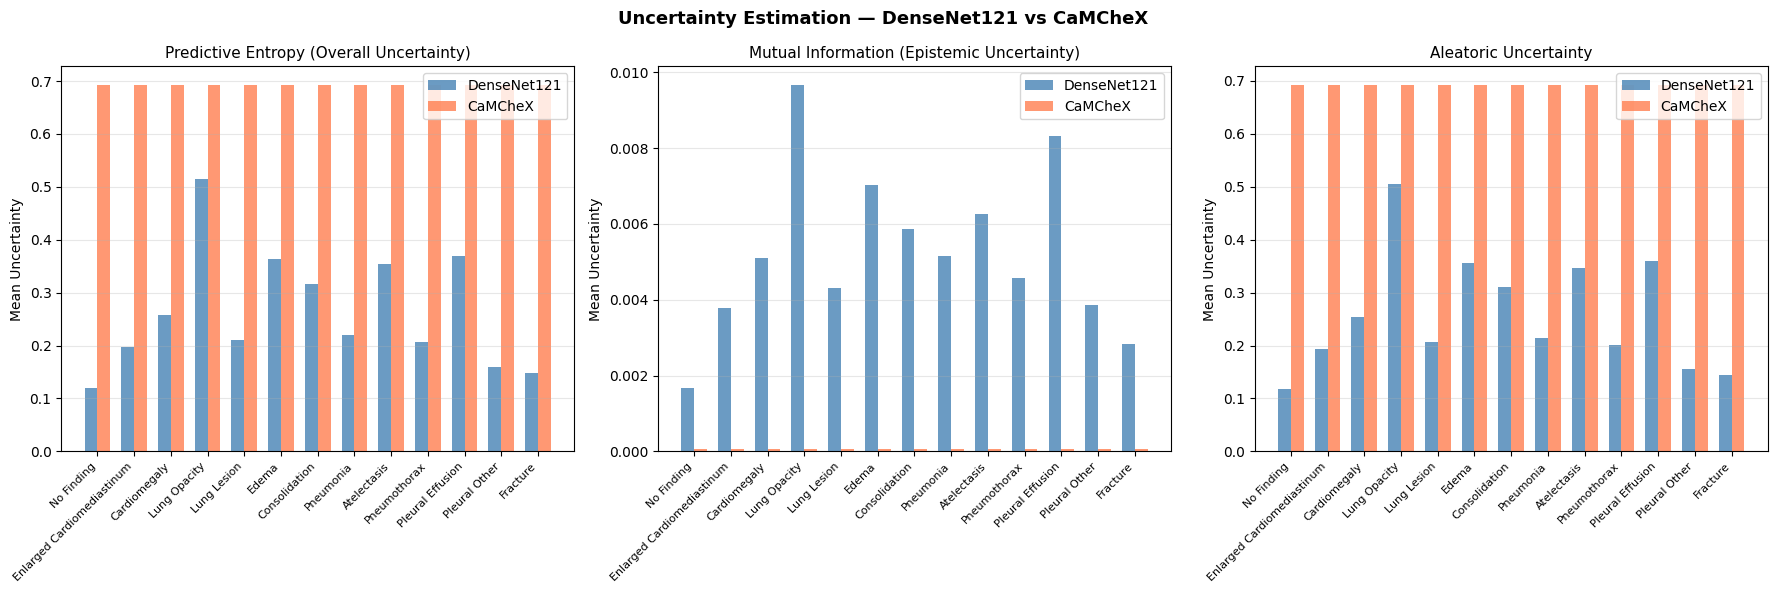

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(disease_cols))
width = 0.35

metrics = [
    ('predictive_entropy', 'Predictive Entropy (Overall Uncertainty)'),
    ('mutual_information', 'Mutual Information (Epistemic Uncertainty)'),
    ('aleatoric',          'Aleatoric Uncertainty'),
]

for ax, (metric, title) in zip(axes, metrics):
    dn_vals = [densenet_uncertainty[metric][:, i].mean() for i in range(len(disease_cols))]
    cx_vals = [camchex_uncertainty[metric][:, i].mean()  for i in range(len(disease_cols))]

    ax.bar(x - width/2, dn_vals, width, label='DenseNet121', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, cx_vals, width, label='CaMCheX',     color='coral',     alpha=0.8)

    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(disease_cols, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean Uncertainty')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Uncertainty Estimation — DenseNet121 vs CaMCheX', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uncertainty_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------

In [37]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2

# ── GradCAM implementation ──────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # Register hooks on target layer
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)

        # Backprop for specific class
        output[0, class_idx].backward()

        # Weight activations by gradients
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:],
                           mode='bilinear', align_corners=False)

        # Normalize to [0, 1]
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, torch.sigmoid(output).detach().cpu().numpy()[0]


def cam_to_bbox(cam, threshold=0.5):
    """Convert CAM heatmap to bounding box"""
    binary = (cam > threshold).astype(np.uint8)
    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        return None
    # Get largest contour
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return x, y, w, h


# ── Main prediction + visualization function ────────────────────
def predict_and_visualize(image_path, model, disease_cols, device,
                          confidence_threshold=0.3, cam_threshold=0.5):
    """
    Given an X-ray image path:
    - Runs model inference
    - Generates GradCAM for each detected disease
    - Draws bounding boxes with confidence scores
    """
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    orig_w, orig_h = image.size

    transform = transforms.Compose([
        transforms.Resize((320, 320)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    input_tensor = transform(image).unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    # Setup GradCAM on last conv layer of DenseNet121
    target_layer = model.features.denseblock4.denselayer16.conv2
    gradcam = GradCAM(model, target_layer)

    model.eval()

    # Find predicted diseases above threshold
    with torch.enable_grad():
        detected = []
        for i, disease in enumerate(disease_cols):
            cam, probs = gradcam.generate(input_tensor, class_idx=i)
            confidence = probs[i]

            if confidence >= confidence_threshold:
                bbox = cam_to_bbox(cam, threshold=cam_threshold)
                detected.append({
                    'disease': disease,
                    'confidence': confidence,
                    'bbox': bbox,
                    'cam': cam
                })

    # ── Plot ────────────────────────────────────────────────────
    colors = plt.cm.tab10(np.linspace(0, 1, len(detected)))

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image, cmap='gray')

    for idx, (det, color) in enumerate(zip(detected, colors)):
        disease   = det['disease']
        conf      = det['confidence']
        bbox      = det['bbox']
        color_hex = color[:3]

        if bbox is not None:
            # Scale bbox from 320x320 back to original image size
            scale_x = orig_w / 320
            scale_y = orig_h / 320
            x, y, w, h = bbox
            x = int(x * scale_x)
            y = int(y * scale_y)
            w = int(w * scale_x)
            h = int(h * scale_y)

            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2,
                edgecolor=color_hex,
                facecolor='none'
            )
            ax.add_patch(rect)

            # Label with disease + confidence
            ax.text(
                x, y - 5,
                f"{disease}  {conf:.2f}",
                color='white',
                fontsize=9,
                fontweight='bold',
                bbox=dict(
                    facecolor=color_hex,
                    alpha=0.7,
                    pad=2,
                    edgecolor='none'
                )
            )

    ax.axis('off')
    ax.set_title('Disease Detection with Confidence Scores', fontsize=13)
    plt.tight_layout()
    plt.savefig('prediction_output.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print summary
    print(f"\nDetected diseases (confidence > {confidence_threshold}):")
    print(f"{'Disease':<35} {'Confidence':>10}")
    print("-" * 48)
    for det in sorted(detected, key=lambda x: x['confidence'], reverse=True):
        print(f"{det['disease']:<35} {det['confidence']:>10.4f}")

    return detected

In [38]:
# Load your best DenseNet121
# For old .pth file — raw state dict
densenet121.load_state_dict(
    torch.load('best_densenet121_uzeros.pth', 
               map_location=device, 
               weights_only=False)
)
densenet121 = densenet121.to(device)



# Run on a sample image from val set
sample_path = resolve_path(val_split_df.iloc[0]['Path_frontal'])
print(f"Running on: {sample_path}")

detected = predict_and_visualize(
    image_path=sample_path,
    model=densenet121,
    disease_cols=disease_cols,
    device=device,
    confidence_threshold=0.3,   # show diseases model is >30% confident about
    cam_threshold=0.5           # threshold for bbox from heatmap
)

NameError: name 'densenet121' is not defined

# Camchex Sample Image test

In [39]:
class CaMCheXGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, frontal_tensor, lateral_tensor, class_idx):
        self.model.zero_grad()

        # Disable checkpointing for GradCAM — needs full graph
        self.model.use_checkpointing = False

        output = self.model(frontal_tensor, lateral_tensor)
        output[0, class_idx].backward()

        # Re-enable checkpointing
        self.model.use_checkpointing = True

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(
            cam,
            size=frontal_tensor.shape[2:],
            mode='bilinear',
            align_corners=False
        )
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, torch.sigmoid(output).detach().cpu().numpy()[0]


def camchex_gradcam_visualize(frontal_image, lateral_image, model, disease_cols,
                               device, confidence_threshold=0.3, cam_threshold=0.5):
    """
    GradCAM for CaMCheX — runs on frontal image, uses both views for prediction.
    Bounding boxes shown on frontal image.
    """
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    orig_w, orig_h = frontal_image.size

    frontal_tensor = transform(frontal_image).unsqueeze(0).to(device)
    lateral_tensor = transform(lateral_image).unsqueeze(0).to(device)
    frontal_tensor.requires_grad_(True)

    # Target last conv block in ConvNeXt-Tiny frontal encoder
    target_layer = model.frontal_encoder.features[7][2].block[0]
    gradcam = CaMCheXGradCAM(model, target_layer)
    model.eval()

    detected = []
    with torch.enable_grad():
        for i, disease in enumerate(disease_cols):
            cam, probs = gradcam.generate(frontal_tensor, lateral_tensor, class_idx=i)
            confidence = probs[i]
            if confidence >= confidence_threshold:
                bbox = cam_to_bbox(cam, threshold=cam_threshold)
                detected.append({
                    'disease': disease,
                    'confidence': float(confidence),
                    'bbox': bbox,
                    'cam': cam
                })

    # Plot on frontal image
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(detected), 1)))
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Left — frontal with bounding boxes
    axes[0].imshow(frontal_image, cmap='gray')
    for det, color in zip(detected, colors):
        bbox = det['bbox']
        color_rgb = color[:3]
        if bbox is not None:
            scale_x = orig_w / 224
            scale_y = orig_h / 224
            x, y, w, h = bbox
            x = int(x * scale_x)
            y = int(y * scale_y)
            w = int(w * scale_x)
            h = int(h * scale_y)
            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2, edgecolor=color_rgb, facecolor='none'
            )
            axes[0].add_patch(rect)
            axes[0].text(
                x, y - 5,
                f"{det['disease']}  {det['confidence']:.2f}",
                color='white', fontsize=8, fontweight='bold',
                bbox=dict(facecolor=color_rgb, alpha=0.7, pad=2, edgecolor='none')
            )
    axes[0].axis('off')
    axes[0].set_title('Frontal — Disease Detection', fontsize=11)

    # Right — lateral image (no boxes, just for reference)
    axes[1].imshow(lateral_image, cmap='gray')
    axes[1].axis('off')
    axes[1].set_title('Lateral — Reference View', fontsize=11)

    plt.suptitle('CaMCheX Dual-View Detection with Confidence Scores', fontsize=13)
    plt.tight_layout()
    plt.savefig('camchex_prediction_output.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nDetected diseases (confidence > {confidence_threshold}):")
    print(f"{'Disease':<35} {'Confidence':>10}")
    print("-" * 48)
    for det in sorted(detected, key=lambda x: x['confidence'], reverse=True):
        print(f"{det['disease']:<35} {det['confidence']:>10.4f}")

    return detected

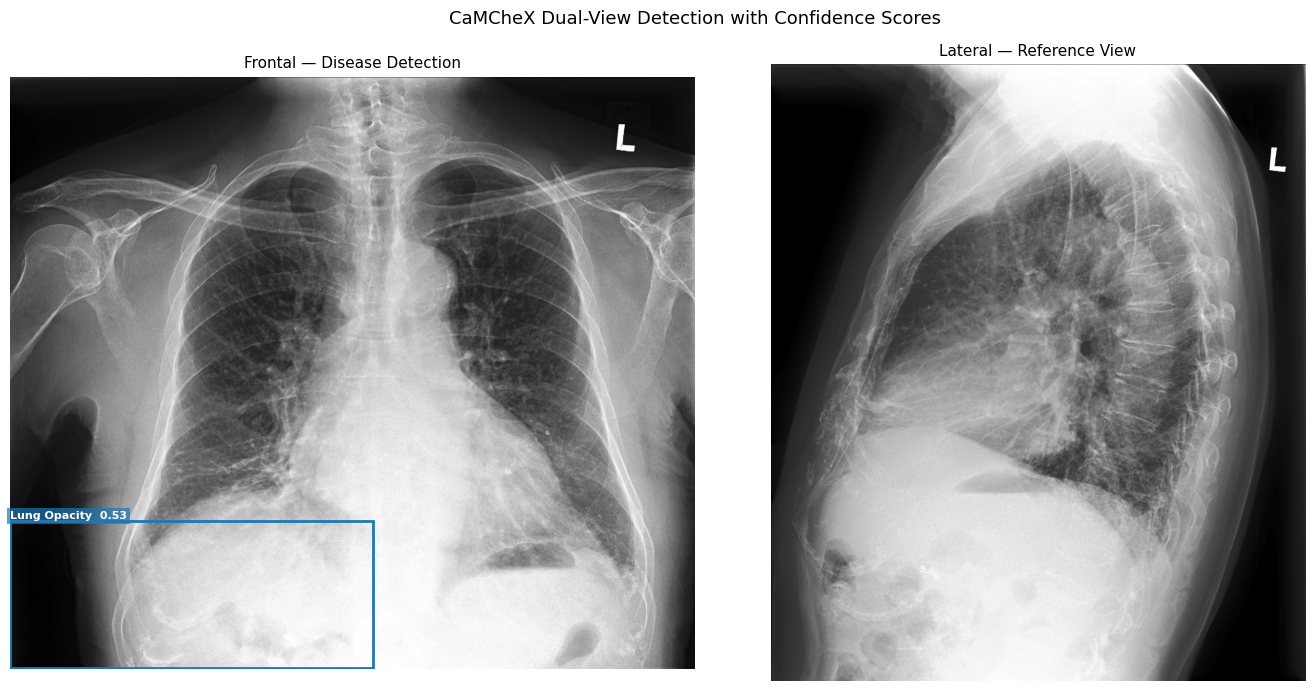


Detected diseases (confidence > 0.3):
Disease                             Confidence
------------------------------------------------
Lung Opacity                            0.5294


In [40]:
# Load best CaMCheX
camchex.load_state_dict(
    torch.load('best_camchex_uzeros.pth', map_location=device, weights_only=False)
)
camchex = camchex.to(device)

# Get a sample from val set
sample_frontal = resolve_path(val_split_df.iloc[0]['Path_frontal'])
sample_lateral  = resolve_path(val_split_df.iloc[0]['Path_lateral'])

frontal_img = Image.open(sample_frontal).convert('RGB')
lateral_img  = Image.open(sample_lateral).convert('RGB')

detected = camchex_gradcam_visualize(
    frontal_image=frontal_img,
    lateral_image=lateral_img,
    model=camchex,
    disease_cols=disease_cols,
    device=device,
    confidence_threshold=0.3,
    cam_threshold=0.5
)

In [41]:
for name, module in camchex.named_modules():
    print(name, "-->", type(module).__name__)

 --> CaMCheXDualView
frontal_encoder --> ConvNeXt
frontal_encoder.features --> Sequential
frontal_encoder.features.0 --> Conv2dNormActivation
frontal_encoder.features.0.0 --> Conv2d
frontal_encoder.features.0.1 --> LayerNorm2d
frontal_encoder.features.1 --> Sequential
frontal_encoder.features.1.0 --> CNBlock
frontal_encoder.features.1.0.block --> Sequential
frontal_encoder.features.1.0.block.0 --> Conv2d
frontal_encoder.features.1.0.block.1 --> Permute
frontal_encoder.features.1.0.block.2 --> LayerNorm
frontal_encoder.features.1.0.block.3 --> Linear
frontal_encoder.features.1.0.block.4 --> GELU
frontal_encoder.features.1.0.block.5 --> Linear
frontal_encoder.features.1.0.block.6 --> Permute
frontal_encoder.features.1.0.stochastic_depth --> StochasticDepth
frontal_encoder.features.1.1 --> CNBlock
frontal_encoder.features.1.1.block --> Sequential
frontal_encoder.features.1.1.block.0 --> Conv2d
frontal_encoder.features.1.1.block.1 --> Permute
frontal_encoder.features.1.1.block.2 --> LayerN